# Universal Fake Image Detection
## Towards Universal Fake Image Detectors that Generalize Across Generative Models

**Paper:** Ojha, U., Li, Y., & Lee, Y. J. - CVPR 2023
**Paper PDF:** https://openaccess.thecvf.com/content/CVPR2023/papers/Ojha_Towards_Universal_Fake_Image_Detectors_That_Generalize_Across_Generative_Models_CVPR_2023_paper.pdf
**arXiv:** https://arxiv.org/abs/2302.10174
**Project Page:** https://utkarshojha.github.io/universal-fake-detection/
**Official GitHub:** https://github.com/WisconsinAIVision/UniversalFakeDetect

---

### Team Members
| Name | Registration No. | Role |
|------|------------------|------|
| Hafsa Saleem | MSCS25004 | Repository setup, data pipeline |
| Amna Ghulam Nabie | MSCS25018 | Model loading & CLIP feature extraction |
| Momna Waryam Khan| MSCS25011 | Code implementation, Evaluation, Metrics, and Demo preparation |

---

### Key Idea of the Paper
Traditional fake-image detectors are trained as a deep binary classifier on REAL vs. FAKE images from one generative model (for example, ProGAN). When tested on images from a different generative family (for example, Diffusion, GLIDE, LDM), they fail badly.

The authors propose a strikingly simple alternative:
1. Take a frozen CLIP ViT-L/14 image encoder (never trained for fake detection)
2. Extract 768-dimensional features from input images
3. Train only a single linear layer on top, for binary classification (REAL vs FAKE)

This tiny model generalizes remarkably well across GANs, diffusion models, and other generative families, beating much heavier supervised baselines.

---

### What is new in this version of the notebook
This notebook has been extended beyond the original demo:

1. **Large real dataset from Kaggle** - the model is now evaluated on the **CIFAKE** dataset (Bird & Lotfi, 2024), a 120,000-image benchmark (60,000 real CIFAR-10 images and 60,000 Stable-Diffusion-generated fakes) downloaded automatically through `kagglehub`. The number of evaluated images is configurable so it still runs comfortably on a Colab GPU.
2. **The small 3-real / 3-fake sample is kept** as a fast fallback when Kaggle credentials are not available.
3. **Image demo works from upload, webcam, and clipboard** - the input sources are now declared explicitly so the camera button always appears.
4. **Video support added** - a separate demo tab samples frames from an uploaded or webcam-recorded video, runs the detector on each sampled frame, and aggregates the per-frame scores into a single REAL/FAKE verdict.

---

### How to run this notebook
1. `File -> Upload notebook` in Colab
2. `Runtime -> Change runtime type -> T4 GPU`
3. Run cells top to bottom
4. Pretrained weights and the CLIP model are downloaded automatically
5. For the Kaggle dataset, add your Kaggle API token when prompted (instructions are in Step 6)

## Step 0: Verify GPU is Enabled
`Runtime -> Change runtime type -> T4 GPU` if not already set.

In [ ]:
import torch, sys, platform

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA avail. : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"CUDA ver.   : {torch.version.cuda}")
else:
    print("No GPU detected. Go to: Runtime -> Change runtime type -> T4 GPU")
print("=" * 60)

ENVIRONMENT CHECK
Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch     : 2.10.0+cu128
CUDA avail. : True
GPU         : Tesla T4
CUDA ver.   : 12.8


## Step 1: Clone the Official UniversalFakeDetect Repository

In [ ]:
# Clone the official repo from the paper authors
%cd /content
!rm -rf UniversalFakeDetect
!git clone https://github.com/WisconsinAIVision/UniversalFakeDetect.git
%cd UniversalFakeDetect
!ls -la

/content
Cloning into 'UniversalFakeDetect'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 126 (delta 24), reused 14 (delta 14), pack-reused 77 (from 2)
Receiving objects: 100% (126/126), 1.65 MiB | 5.11 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/UniversalFakeDetect
total 72
drwxr-xr-x 9 root root 4096 May 20 09:08 .
drwxr-xr-x 1 root root 4096 May 20 09:08 ..
drwxr-xr-x 3 root root 4096 May 20 09:08 data
-rw-r--r-- 1 root root 3448 May 20 09:08 dataset_paths.py
drwxr-xr-x 8 root root 4096 May 20 09:08 .git
-rw-r--r-- 1 root root 1091 May 20 09:08 LICENSE
drwxr-xr-x 3 root root 4096 May 20 09:08 models
drwxr-xr-x 2 root root 4096 May 20 09:08 networks
drwxr-xr-x 2 root root 4096 May 20 09:08 options
drwxr-xr-x 2 root root 4096 May 20 09:08 pretrained_weights
-rw-r--r-- 1 root root 5375 May 20 09:08 README.md
drwxr-xr-x 2 root root 4096 May 20 09:08 resources
-rw-r--

## Step 2: Install Required Libraries

The repository needs:
- `torch`, `torchvision` (pre-installed in Colab)
- `ftfy`, `regex` (CLIP tokenizer requirements)
- `git+https://github.com/openai/CLIP.git` (OpenAI's CLIP model)
- `scikit-learn`, `matplotlib`, `seaborn`, `gradio` for evaluation and demo
- `kagglehub` for downloading the large CIFAKE dataset
- `opencv-python` for reading video frames

In [ ]:
# Install OpenAI CLIP and other dependencies
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q scikit-learn matplotlib seaborn pillow gradio kagglehub opencv-python-headless

# Verify CLIP loads
import clip
print("Available CLIP models:", clip.available_models())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Available CLIP models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


## Step 3: Download Pre-trained Linear Classifier Weights

The authors provide a tiny pre-trained `fc_weights.pth` file (only the linear-layer weights, under 5 MB). With these, the full evaluation can run immediately, without any training.

In [ ]:
import os, urllib.request

os.makedirs('pretrained_weights', exist_ok=True)
weights_path = 'pretrained_weights/fc_weights.pth'

# Official link from the project page (Wisconsin AI Vision)
WEIGHTS_URL = "https://pages.cs.wisc.edu/~yongjaelee/projects/universal_fake_detect/fc_weights.pth"

if not os.path.exists(weights_path):
    print(f"Downloading pre-trained weights from:\n   {WEIGHTS_URL}")
    try:
        urllib.request.urlretrieve(WEIGHTS_URL, weights_path)
        print(f"Downloaded to {weights_path}")
    except Exception as e:
        print(f"Direct download failed: {e}")
        print("\nFallback: download manually from the project page:")
        print("   https://utkarshojha.github.io/universal-fake-detection/")
        print("   Then upload fc_weights.pth into the pretrained_weights/ folder")
else:
    print(f"Weights already present at {weights_path}")

# Verify file size
if os.path.exists(weights_path):
    size_kb = os.path.getsize(weights_path) / 1024
    print(f"   File size: {size_kb:.2f} KB")

Weights already present at pretrained_weights/fc_weights.pth
   File size: 3.99 KB


## Step 4: Understand the Repository Structure

```
UniversalFakeDetect/
  data/                  Dataset loaders
  models/                Model wrappers (CLIPModel etc.)
  networks/              Network architectures
  options/               Argument parsers
  pretrained_weights/    fc_weights.pth lives here
  dataset_paths.py       Test set domain paths
  train.py               Training script
  validate.py            Evaluation script
  test.sh                Quick-run shell script
```

In [ ]:
# Browse the key source files
import os

for fname in ['train.py', 'validate.py', 'dataset_paths.py']:
    if os.path.exists(fname):
        print(f"\n{fname}  ({os.path.getsize(fname)} bytes)")
        print("-" * 60)

print("\nmodels/")
!ls -la models/

print("\nnetworks/")
!ls -la networks/


train.py  (3087 bytes)
------------------------------------------------------------

validate.py  (9849 bytes)
------------------------------------------------------------

dataset_paths.py  (3448 bytes)
------------------------------------------------------------

models/
total 96
drwxr-xr-x 3 root root  4096 May 20 09:08 .
drwxr-xr-x 9 root root  4096 May 20 09:08 ..
drwxr-xr-x 3 root root  4096 May 20 09:08 clip
-rwxr-xr-x 1 root root   643 May 20 09:08 clip_models.py
-rwxr-xr-x 1 root root   942 May 20 09:08 imagenet_models.py
-rwxr-xr-x 1 root root   869 May 20 09:08 __init__.py
-rwxr-xr-x 1 root root 12741 May 20 09:08 resnet.py
-rwxr-xr-x 1 root root  3423 May 20 09:08 vgg.py
-rwxr-xr-x 1 root root  6556 May 20 09:08 vision_transformer_misc.py
-rwxr-xr-x 1 root root 17416 May 20 09:08 vision_transformer.py
-rwxr-xr-x 1 root root 21551 May 20 09:08 vision_transformer_utils.py

networks/
total 40
drwxr-xr-x 2 root root  4096 May 20 09:08 .
drwxr-xr-x 9 root root  4096 May 20 09:0

## Step 5: Build the Universal Fake Detector

The model is intentionally minimal:

```
Input image (224x224)
        |
[CLIP ViT-L/14 frozen encoder]   no gradients, never trained
        |
 768-dim feature vector
        |
[Linear(768 -> 1)]                only this layer is trained
        |
   Sigmoid -> P(FAKE)
```

In [ ]:
import torch
import torch.nn as nn
import clip
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class UniversalFakeDetector(nn.Module):
    """
    Re-implementation of the Ojha et al. (CVPR 2023) detector:
      - Frozen CLIP ViT-L/14 image encoder
      - Single Linear(768 -> 1) classifier head
    """
    def __init__(self, ckpt_path='pretrained_weights/fc_weights.pth'):
        super().__init__()

        # 1. Load frozen CLIP ViT-L/14
        print("Loading CLIP ViT-L/14 (this may take about a minute on first run)...")
        self.clip_model, self.preprocess = clip.load("ViT-L/14", device=device)
        self.clip_model.eval()

        # Freeze CLIP, exactly as the paper specifies (--fix_backbone flag)
        for p in self.clip_model.parameters():
            p.requires_grad = False

        # 2. Linear classifier head: 768 (CLIP ViT-L/14 image features) -> 1 logit
        self.fc = nn.Linear(768, 1)

        # 3. Load pre-trained weights if available
        if os.path.exists(ckpt_path):
            state = torch.load(ckpt_path, map_location=device)
            try:
                self.fc.load_state_dict(state)
                print(f"Loaded pre-trained FC weights from {ckpt_path}")
            except Exception:
                # Sometimes saved as a dict with 'fc.weight','fc.bias' keys
                new_state = {}
                for k, v in state.items():
                    new_state[k.replace('fc.', '')] = v
                self.fc.load_state_dict(new_state)
                print(f"Loaded pre-trained FC weights (re-keyed) from {ckpt_path}")
        else:
            print(f"No checkpoint at {ckpt_path}, model has random FC weights")

        self.to(device)

    @torch.no_grad()
    def extract_features(self, images):
        """images: (B, 3, 224, 224) tensor already preprocessed by CLIP transforms."""
        feats = self.clip_model.encode_image(images)
        return feats.float()

    def forward(self, images):
        feats = self.extract_features(images)   # (B, 768)
        logits = self.fc(feats)                 # (B, 1)
        return logits.squeeze(-1)               # (B,)

    @torch.no_grad()
    def predict(self, pil_image):
        """Predict on one PIL image. Returns (label, fake_probability)."""
        self.eval()
        x = self.preprocess(pil_image).unsqueeze(0).to(device)
        logit = self.forward(x)
        prob_fake = torch.sigmoid(logit).item()
        label = "FAKE" if prob_fake > 0.5 else "REAL"
        return label, prob_fake


# Build the detector
detector = UniversalFakeDetector(ckpt_path='pretrained_weights/fc_weights.pth')
detector.eval()

trainable = sum(p.numel() for p in detector.parameters() if p.requires_grad)
total     = sum(p.numel() for p in detector.parameters())
print(f"\nTotal params     : {total:,}")
print(f"Trainable params : {trainable:,}   (only the linear layer)")
print(f"Frozen CLIP      : {total - trainable:,}")

Loading CLIP ViT-L/14 (this may take about a minute on first run)...


100%|███████████████████████████████████████| 890M/890M [00:11<00:00, 79.0MiB/s]


Loaded pre-trained FC weights from pretrained_weights/fc_weights.pth

Total params     : 427,617,282
Trainable params : 769   (only the linear layer)
Frozen CLIP      : 427,616,513


## Step 6: Load the 140k Real and Fake Faces Dataset

This cell does the following, in order, **without re-downloading every time**:

1. **Checks Google Drive first.** If the extracted dataset is already cached at `/content/drive/MyDrive/datasets/140kFaces/`, it uses that directly. Takes ~30 seconds.
2. **Otherwise, looks for `archive.zip`** in `/content/` or `/content/UniversalFakeDetect/`. If found, it extracts the ZIP (~2-3 minutes for the 4 GB file), copies the test split to Drive, then uses it. Takes ~5-10 minutes on first run.
3. **Copies a balanced sample** of `N_PER_CLASS` real and fake images into `test_data/0_real/` and `test_data/1_fake/` in the format the rest of the notebook expects.

### Before running this cell

- Make sure `archive.zip` is uploaded to `/content/` (you can see it in the file panel on the left).
- If you ran Cell 1 (`%cd /content/UniversalFakeDetect`), `archive.zip` might be in the parent folder — both locations are checked automatically.
- If Google Drive is not yet mounted, this cell mounts it.

### Expected output on first run

```
Mounting Google Drive...
Drive mounted at /content/drive
Drive cache not found.
Looking for archive.zip...
Found archive.zip at /content/archive.zip (size: 4.13 GB)
Extracting (~2-3 minutes for 4 GB)...
Done extracting.
Found real folder: extracted/real_vs_fake/real-vs-fake/test/real
Found fake folder: extracted/real_vs_fake/real-vs-fake/test/fake
Caching test split to Drive at /content/drive/MyDrive/datasets/140kFaces ...
Caching done.
Copied 500 real and 500 fake images into test_data/
Sample image: 00000.jpg  256x256 px  JPEG
```

### Expected output on later runs

```
Drive already mounted.
Found cached dataset on Drive.
Copied 500 real and 500 fake images into test_data/
Sample image: 00000.jpg  256x256 px  JPEG
```

In [ ]:
# ====== CONFIGURATION ===================================================
N_PER_CLASS = 500
SPLIT = "test"
DRIVE_CACHE = "/content/drive/MyDrive/datasets/140kFaces"
KAGGLE_DATASET = "xhlulu/140k-real-and-fake-faces"

# Option 1: paste your Kaggle credentials here (will be saved in the notebook).
# Leave blank if you set Colab Secrets instead.
KAGGLE_USERNAME = "momnakhan"
KAGGLE_KEY      = "abc123yournewkeyhere456def" # your NEW key from kaggle.com/settings/api
# ========================================================================

import os, glob, random, shutil, zipfile, json, stat, subprocess, sys
from pathlib import Path
from PIL import Image

# Step A - Mount Drive
DRIVE_OK = False
try:
    from google.colab import drive
    if os.path.ismount("/content/drive"):
        print("Drive already mounted.")
    else:
        drive.mount("/content/drive")
        print("Drive mounted at /content/drive")
    DRIVE_OK = True
except Exception as e:
    print(f"Could not mount Drive ({e}). Continuing without persistence.")

# Step B - Reset test_data
shutil.rmtree("test_data", ignore_errors=True)
os.makedirs("test_data/0_real", exist_ok=True)
os.makedirs("test_data/1_fake", exist_ok=True)

# Step C - Helpers
def find_class_folders(root, split):
    root = Path(root)
    real_hits = [p for p in root.rglob(f"{split}/real") if p.is_dir()]
    fake_hits = [p for p in root.rglob(f"{split}/fake") if p.is_dir()]
    return (real_hits[0] if real_hits else None,
            fake_hits[0] if fake_hits else None)

def sample_copy(src_dir, dst_dir, n):
    files = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        files += list(Path(src_dir).rglob(ext))
        files += list(Path(src_dir).rglob(ext.upper()))
    random.seed(42)
    random.shuffle(files)
    files = files[:n]
    for i, fp in enumerate(files):
        shutil.copy(fp, Path(dst_dir) / f"{i:05d}{fp.suffix.lower()}")
    return len(files)


real_src, fake_src = None, None

# Step D - Drive cache check
if DRIVE_OK and os.path.isdir(DRIVE_CACHE):
    print(f"\nChecking Drive cache at {DRIVE_CACHE} ...")
    real_src, fake_src = find_class_folders(DRIVE_CACHE, SPLIT)
    if real_src and fake_src:
        print("Found cached dataset on Drive. Skipping Kaggle download.")
    else:
        real_src, fake_src = None, None

# Step E - Set up Kaggle credentials
def setup_kaggle_credentials():
    cred_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(cred_path):
        print("Found existing ~/.kaggle/kaggle.json")
        return True

    # Try Colab Secrets first
    try:
        from google.colab import userdata
        u = userdata.get("KAGGLE_USERNAME")
        k = userdata.get("KAGGLE_KEY")
        if u and k:
            os.makedirs(os.path.dirname(cred_path), exist_ok=True)
            with open(cred_path, "w") as f:
                json.dump({"username": u.strip(), "key": k.strip()}, f)
            os.chmod(cred_path, stat.S_IRUSR | stat.S_IWUSR)
            os.environ["KAGGLE_USERNAME"] = u.strip()
            os.environ["KAGGLE_KEY"] = k.strip()
            print("Loaded Kaggle credentials from Colab Secrets.")
            return True
    except Exception:
        pass

    # Fall back to the variables in this cell
    if KAGGLE_USERNAME.strip() and KAGGLE_KEY.strip():
        os.makedirs(os.path.dirname(cred_path), exist_ok=True)
        with open(cred_path, "w") as f:
            json.dump({"username": KAGGLE_USERNAME.strip(),
                       "key": KAGGLE_KEY.strip()}, f)
        os.chmod(cred_path, stat.S_IRUSR | stat.S_IWUSR)
        os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME.strip()
        os.environ["KAGGLE_KEY"] = KAGGLE_KEY.strip()
        print("Saved Kaggle credentials from this cell's variables.")
        return True

    return False

# Step F - Download from Kaggle if we don't have it cached
if real_src is None:
    if not setup_kaggle_credentials():
        raise RuntimeError(
            "\nNo Kaggle credentials.\n"
            "Either:\n"
            "  - Set Colab Secrets KAGGLE_USERNAME and KAGGLE_KEY (key icon in sidebar), or\n"
            "  - Fill KAGGLE_USERNAME and KAGGLE_KEY at the top of this cell\n"
            "Get a token from https://www.kaggle.com/settings/api (Create New Token)."
        )

    # Install kaggle CLI quietly
    print("\nInstalling kaggle CLI...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"],
                   check=True)

    download_dir = Path("/content/kaggle_download")
    download_dir.mkdir(exist_ok=True)

    # Skip download if zip already there
    existing = list(download_dir.glob("*.zip"))
    if existing and existing[0].stat().st_size > 100 * 1024 * 1024:
        print(f"Already downloaded: {existing[0]} "
              f"({existing[0].stat().st_size/1e9:.2f} GB)")
        zip_path = existing[0]
    else:
        print(f"Downloading {KAGGLE_DATASET} from Kaggle (~4 GB, "
              f"usually 1-3 minutes on Colab's network)...")
        # --unzip would extract too but we want control over the location
        result = subprocess.run(
            ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET,
             "-p", str(download_dir)],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            print("STDOUT:", result.stdout)
            print("STDERR:", result.stderr)
            raise RuntimeError(
                "Kaggle download failed. Common causes:\n"
                "  - Wrong username or key\n"
                "  - You haven't accepted the dataset terms on Kaggle's website "
                f"(visit https://www.kaggle.com/datasets/{KAGGLE_DATASET} "
                "and click 'I Understand and Accept')\n"
            )
        zips = list(download_dir.glob("*.zip"))
        if not zips:
            raise RuntimeError(f"Download produced no zip in {download_dir}")
        zip_path = zips[0]
        print(f"Downloaded {zip_path} ({zip_path.stat().st_size/1e9:.2f} GB)")

    # Validate
    if not zipfile.is_zipfile(zip_path):
        raise RuntimeError(f"{zip_path} is not a valid zip. Re-download.")

    # Extract
    extract_root = Path("/content/UniversalFakeDetect/extracted")
    if extract_root.exists() and any(extract_root.iterdir()):
        print(f"\n{extract_root} already populated; skipping extraction.")
    else:
        extract_root.mkdir(parents=True, exist_ok=True)
        print("\nExtracting (2-3 minutes)...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_root)
        print("Done extracting.")

    real_src, fake_src = find_class_folders(extract_root, SPLIT)
    if not real_src or not fake_src:
        print("Could not find real/fake folders. First 30 extracted entries:")
        for p in sorted(extract_root.rglob("*"))[:30]:
            print(f"  {p}")
        raise RuntimeError(f"No */{SPLIT}/real or */{SPLIT}/fake folders found.")

    print(f"Real folder: {real_src}")
    print(f"Fake folder: {fake_src}")

    # Cache to Drive
    if DRIVE_OK:
        cache_real = Path(DRIVE_CACHE) / SPLIT / "real"
        cache_fake = Path(DRIVE_CACHE) / SPLIT / "fake"
        if not (cache_real.is_dir() and any(cache_real.iterdir()) and
                cache_fake.is_dir() and any(cache_fake.iterdir())):
            print(f"\nCaching to Drive at {DRIVE_CACHE} (one-time, ~5 min)...")
            cache_real.mkdir(parents=True, exist_ok=True)
            cache_fake.mkdir(parents=True, exist_ok=True)
            for fp in Path(real_src).iterdir():
                if fp.is_file():
                    shutil.copy(fp, cache_real / fp.name)
            for fp in Path(fake_src).iterdir():
                if fp.is_file():
                    shutil.copy(fp, cache_fake / fp.name)
            print("Drive cache saved. Future runs will be instant.")
            real_src, fake_src = cache_real, cache_fake

# Step G - Copy balanced sample to test_data/
n_real = sample_copy(real_src, "test_data/0_real", N_PER_CLASS)
n_fake = sample_copy(fake_src, "test_data/1_fake", N_PER_CLASS)
print(f"\nCopied {n_real} real and {n_fake} fake images into test_data/")

# Step H - Sanity check
sample_path = sorted(os.listdir("test_data/0_real"))[0]
with Image.open(f"test_data/0_real/{sample_path}") as im:
    print(f"Sample image: {sample_path}  {im.size[0]}x{im.size[1]} px  {im.format}")
    if max(im.size) < 100:
        print("\nWARNING: images are very small. Wrong dataset extracted.")
    else:
        print("Resolution looks correct for the 140k Faces dataset (256x256).")

Drive already mounted.
Saved Kaggle credentials from this cell's variables.

Installing kaggle CLI...
Downloaded /content/kaggle_download/140k-real-and-fake-faces.zip (4.02 GB)

Extracting (2-3 minutes)...
Done extracting.
Real folder: /content/UniversalFakeDetect/extracted/real_vs_fake/real-vs-fake/test/real
Fake folder: /content/UniversalFakeDetect/extracted/real_vs_fake/real-vs-fake/test/fake

Caching to Drive at /content/drive/MyDrive/datasets/140kFaces (one-time, ~5 min)...
Drive cache saved. Future runs will be instant.

Copied 500 real and 500 fake images into test_data/
Sample image: 00000.jpg  256x256 px  JPEG
Resolution looks correct for the 140k Faces dataset (256x256).


## Step 7: Preview the Data (10 Real + 10 Fake)

Shows a 2x10 grid of the actual images currently in `test_data/`. Each tile is sized to the image's native resolution so 256x256 faces look sharp.

**Why this matters:** if the preview is blurry, either the dataset is at the wrong resolution (e.g. 32x32 CIFAKE) or the matplotlib tile size is too large. The cell below prints the resolution of every image so you can confirm it's loaded correctly.

**Expected output:**
- One log line per image saying e.g. `REAL[0]: 00000.jpg  256x256 px  18.4 KB`
- A 2-row × 10-column figure showing 10 real faces on top and 10 fake faces below
- All faces should look sharp and recognizable. StyleGAN-generated fakes sometimes have visible artifacts around the hair, ears, or background.

test_data/0_real: 500 files
test_data/1_fake: 500 files

Real images:
  REAL[ 0]: 00000.jpg              256x256     22.5 KB
  REAL[ 1]: 00001.jpg              256x256     30.7 KB
  REAL[ 2]: 00002.jpg              256x256     34.7 KB
  REAL[ 3]: 00003.jpg              256x256     30.0 KB
  REAL[ 4]: 00004.jpg              256x256     28.0 KB
  REAL[ 5]: 00005.jpg              256x256     23.0 KB
  REAL[ 6]: 00006.jpg              256x256     28.4 KB
  REAL[ 7]: 00007.jpg              256x256     28.0 KB
  REAL[ 8]: 00008.jpg              256x256     28.8 KB
  REAL[ 9]: 00009.jpg              256x256     32.9 KB

Fake images:
  FAKE[ 0]: 00000.jpg              256x256     30.1 KB
  FAKE[ 1]: 00001.jpg              256x256     24.6 KB
  FAKE[ 2]: 00002.jpg              256x256     28.2 KB
  FAKE[ 3]: 00003.jpg              256x256     28.6 KB
  FAKE[ 4]: 00004.jpg              256x256     32.8 KB
  FAKE[ 5]: 00005.jpg              256x256     23.9 KB
  FAKE[ 6]: 00006.jpg              2

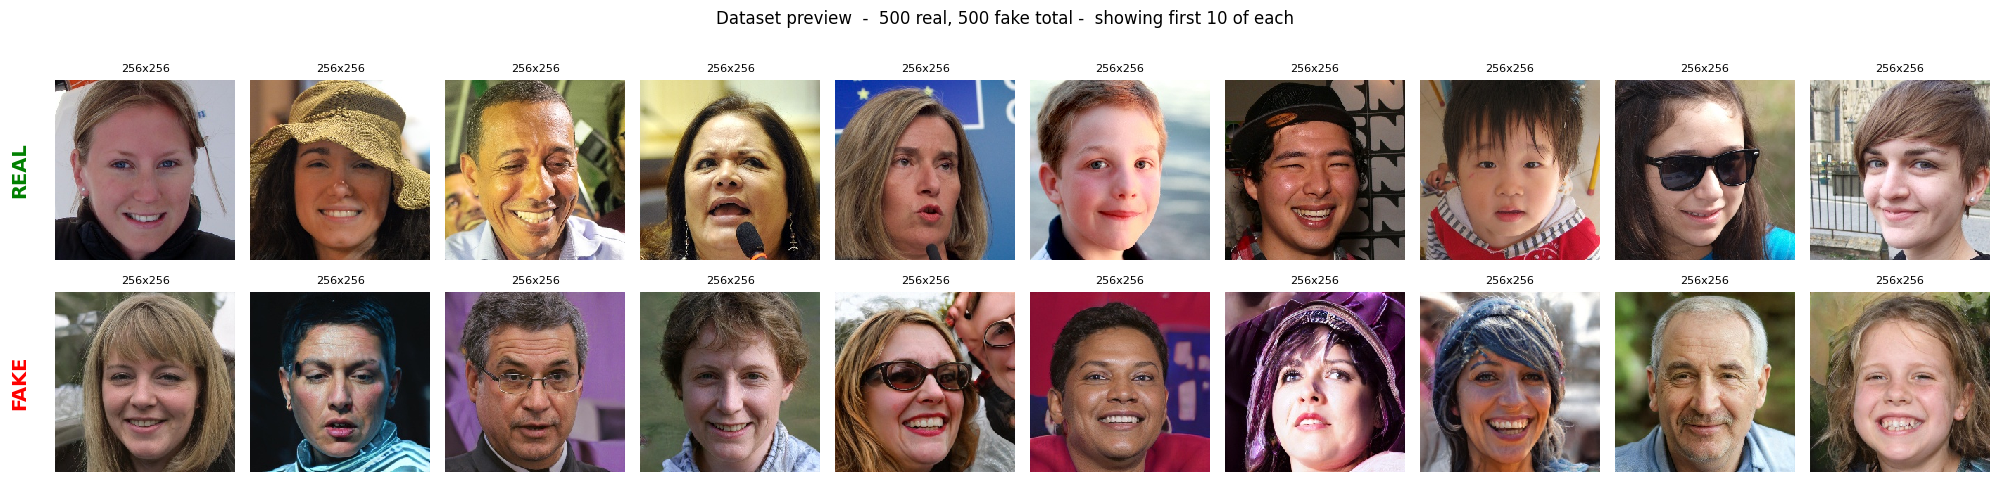


If the faces above look sharp and recognizable, you are good to go.


In [ ]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# How many of each to show
N_SHOW = 10

real_files = sorted(f for f in os.listdir("test_data/0_real") if not f.startswith("."))
fake_files = sorted(f for f in os.listdir("test_data/1_fake") if not f.startswith("."))
print(f"test_data/0_real: {len(real_files)} files")
print(f"test_data/1_fake: {len(fake_files)} files")

if not real_files or not fake_files:
    raise RuntimeError("No images in test_data/. Re-run Step 6 first.")

# Take the first N_SHOW from each (sorted, so deterministic)
show_real = real_files[:N_SHOW]
show_fake = fake_files[:N_SHOW]
n_cols = max(len(show_real), len(show_fake))

# Log the resolution of every image so we know what we are dealing with
print("\nReal images:")
for i, f in enumerate(show_real):
    p = f"test_data/0_real/{f}"
    with PILImage.open(p) as im:
        print(f"  REAL[{i:2d}]: {f:20s}  {im.size[0]:4d}x{im.size[1]:<4d}  "
              f"{os.path.getsize(p)/1024:6.1f} KB")
print("\nFake images:")
for i, f in enumerate(show_fake):
    p = f"test_data/1_fake/{f}"
    with PILImage.open(p) as im:
        print(f"  FAKE[{i:2d}]: {f:20s}  {im.size[0]:4d}x{im.size[1]:<4d}  "
              f"{os.path.getsize(p)/1024:6.1f} KB")

# Build the 2 x N_SHOW grid
# Tile width 2.0 inches keeps small (32x32) images from being upscaled too much,
# but is still wide enough to see 256x256 sharply.
fig, axes = plt.subplots(2, n_cols, figsize=(2.0 * n_cols, 5.0), squeeze=False)

for col in range(n_cols):
    # REAL row
    ax = axes[0, col]
    if col < len(show_real):
        img = PILImage.open(f"test_data/0_real/{show_real[col]}").convert("RGB")
        ax.imshow(img, interpolation="nearest")
        ax.set_title(f"{img.size[0]}x{img.size[1]}", fontsize=8)
    else:
        ax.text(0.5, 0.5, "(none)", ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="gray")
    ax.axis("off")
    if col == 0:
        ax.text(-0.20, 0.5, "REAL", transform=ax.transAxes,
                fontsize=14, fontweight="bold", color="green",
                rotation=90, va="center", ha="center")

    # FAKE row
    ax = axes[1, col]
    if col < len(show_fake):
        img = PILImage.open(f"test_data/1_fake/{show_fake[col]}").convert("RGB")
        ax.imshow(img, interpolation="nearest")
        ax.set_title(f"{img.size[0]}x{img.size[1]}", fontsize=8)
    else:
        ax.text(0.5, 0.5, "(none)", ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="gray")
    ax.axis("off")
    if col == 0:
        ax.text(-0.20, 0.5, "FAKE", transform=ax.transAxes,
                fontsize=14, fontweight="bold", color="red",
                rotation=90, va="center", ha="center")

plt.suptitle(f"Dataset preview  -  {len(real_files)} real, {len(fake_files)} fake total "
             f"-  showing first {n_cols} of each",
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig("test_data_preview.png", dpi=120, bbox_inches="tight")
print("\nPreview saved to test_data_preview.png")
plt.show()
print("\nIf the faces above look sharp and recognizable, you are good to go.")

## Step 8: PyTorch Dataset and DataLoader

We use the same folder layout as the official repo:
- `0_real/` produces label 0 (REAL)
- `1_fake/` produces label 1 (FAKE)

The CLIP preprocessing transform (already loaded in the model) handles resizing, center crop, and normalization.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import glob

class RealFakeDataset(Dataset):
    """Dataset following the repo's 0_real/ and 1_fake/ folder convention."""
    def __init__(self, root, transform=None,
                 extensions=('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
        self.transform = transform
        self.paths, self.labels = [], []

        real_dir = os.path.join(root, '0_real')
        fake_dir = os.path.join(root, '1_fake')

        for ext in extensions:
            for p in (glob.glob(os.path.join(real_dir, f'*{ext}')) +
                      glob.glob(os.path.join(real_dir, f'*{ext.upper()}'))):
                self.paths.append(p); self.labels.append(0)
            for p in (glob.glob(os.path.join(fake_dir, f'*{ext}')) +
                      glob.glob(os.path.join(fake_dir, f'*{ext.upper()}'))):
                self.paths.append(p); self.labels.append(1)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx], self.paths[idx]


# Build the dataset using CLIP's official preprocessing
test_dataset = RealFakeDataset('test_data', transform=detector.preprocess)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Test dataset: {len(test_dataset)} images")
print(f"   REAL: {test_dataset.labels.count(0)}")
print(f"   FAKE: {test_dataset.labels.count(1)}")

Test dataset: 1000 images
   REAL: 500
   FAKE: 500


## Step 9: Evaluate the Pre-trained Model

We compute exactly the metrics used in the paper:
- Average Precision (AP), the primary metric in Tables 1 and 2 of the paper
- Accuracy, using 0.5 as the threshold on the sigmoid output
- Plus standard helpers: Precision, Recall, F1, ROC-AUC, Confusion Matrix

In [ ]:
from sklearn.metrics import (
    average_precision_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
from tqdm.notebook import tqdm

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels, all_paths = [], [], []

    for imgs, labels, paths in tqdm(loader, desc='Evaluating'):
        imgs = imgs.to(device)
        logits = model(imgs)
        all_logits.extend(logits.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist()
                          if hasattr(labels, 'numpy') else list(labels))
        all_paths.extend(paths)

    logits = np.array(all_logits)
    labels_arr = np.array(all_labels)
    probs = 1.0 / (1.0 + np.exp(-logits))   # sigmoid
    preds = (probs > 0.5).astype(int)
    return logits, probs, preds, labels_arr, all_paths


if len(test_dataset) > 0:
    logits, probs, preds, labels_arr, paths = evaluate(detector, test_loader)

    print("=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    print(f"Test images   : {len(labels_arr)}")
    if len(np.unique(labels_arr)) > 1:
        print(f"Average Prec. : {average_precision_score(labels_arr, probs):.4f}   (paper main metric)")
        print(f"ROC-AUC       : {roc_auc_score(labels_arr, probs):.4f}")
    print(f"Accuracy      : {accuracy_score(labels_arr, preds):.4f}")
    print(f"Precision     : {precision_score(labels_arr, preds, zero_division=0):.4f}")
    print(f"Recall        : {recall_score(labels_arr, preds, zero_division=0):.4f}")
    print(f"F1-Score      : {f1_score(labels_arr, preds, zero_division=0):.4f}")
    print("=" * 60)
    print("\nClassification Report:")
    print(classification_report(labels_arr, preds,
                                target_names=['REAL', 'FAKE'], zero_division=0))
else:
    print("No images found in test_data/. Run Step 6 first.")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

EVALUATION RESULTS
Test images   : 1000
Average Prec. : 0.9669   (paper main metric)
ROC-AUC       : 0.9630
Accuracy      : 0.8490
Precision     : 0.9729
Recall        : 0.7180
F1-Score      : 0.8262

Classification Report:
              precision    recall  f1-score   support

        REAL       0.78      0.98      0.87       500
        FAKE       0.97      0.72      0.83       500

    accuracy                           0.85      1000
   macro avg       0.87      0.85      0.85      1000
weighted avg       0.87      0.85      0.85      1000



## Step 10: Visualize Results

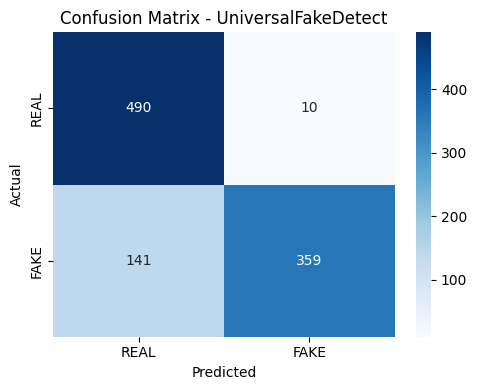

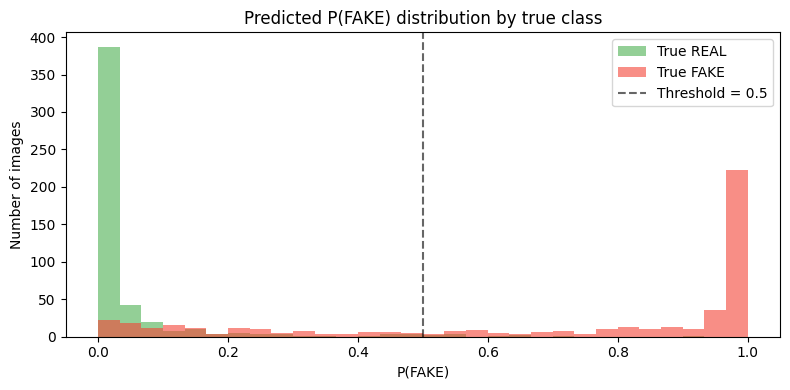

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(test_dataset) > 0:
    # 1. Confusion Matrix
    cm = confusion_matrix(labels_arr, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
    plt.title('Confusion Matrix - UniversalFakeDetect')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    # 2. Probability distribution by true class (works for large datasets too)
    plt.figure(figsize=(8, 4))
    real_probs = probs[labels_arr == 0]
    fake_probs = probs[labels_arr == 1]
    bins = np.linspace(0, 1, 31)
    plt.hist(real_probs, bins=bins, alpha=0.6, label='True REAL', color='#4CAF50')
    plt.hist(fake_probs, bins=bins, alpha=0.6, label='True FAKE', color='#F44336')
    plt.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Threshold = 0.5')
    plt.xlabel('P(FAKE)')
    plt.ylabel('Number of images')
    plt.title('Predicted P(FAKE) distribution by true class')
    plt.legend()
    plt.tight_layout(); plt.show()

## Step 11: Inspect Some Predictions Visually

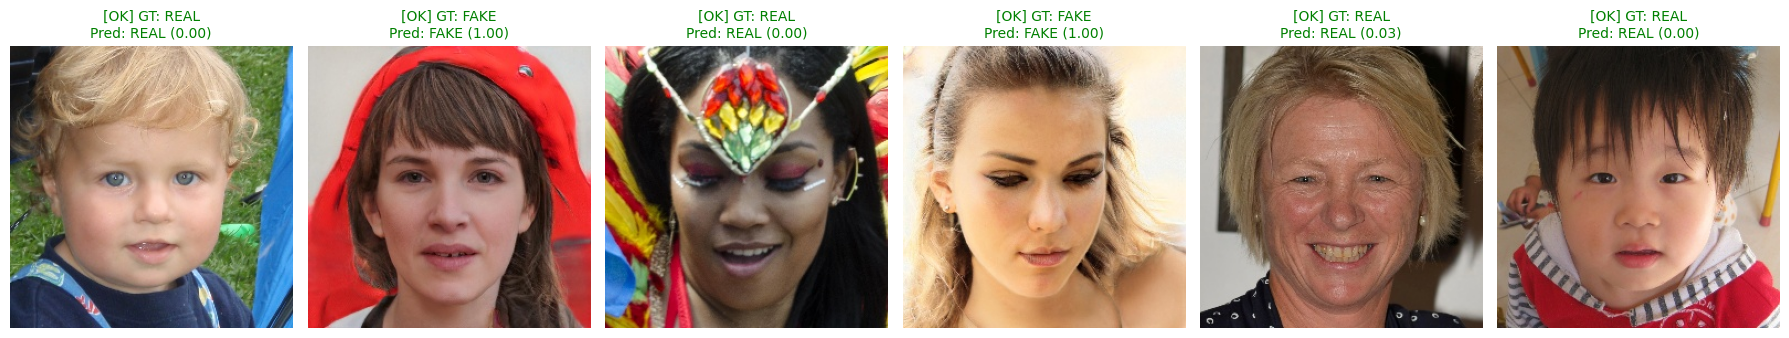

In [ ]:
from PIL import Image

if len(test_dataset) > 0:
    # Show a random sample so large datasets are represented fairly
    import random
    random.seed(0)
    idxs = list(range(len(paths)))
    random.shuffle(idxs)
    n_show = min(6, len(idxs))
    idxs = idxs[:n_show]

    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for ax, i in zip(axes, idxs):
        img = Image.open(paths[i]).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        gt = 'REAL' if labels_arr[i] == 0 else 'FAKE'
        pred = 'REAL' if preds[i] == 0 else 'FAKE'
        mark = 'OK' if preds[i] == labels_arr[i] else 'X'
        color = 'green' if preds[i] == labels_arr[i] else 'red'
        ax.set_title(f'[{mark}] GT: {gt}\nPred: {pred} ({probs[i]:.2f})',
                     color=color, fontsize=10)
    plt.tight_layout(); plt.show()

## Step 12: Predict on a Single New Image

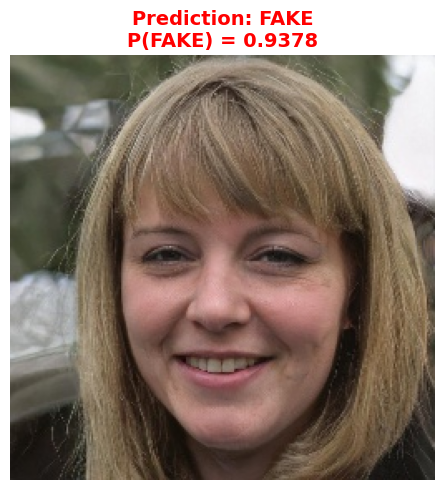


test_data/1_fake/00000.jpg
   Prediction: FAKE
   P(FAKE)   : 0.9378


In [ ]:
def predict_single_image(image_path, model=detector, show=True):
    img = Image.open(image_path).convert('RGB')
    label, prob_fake = model.predict(img)

    if show:
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        color = 'red' if label == 'FAKE' else 'green'
        plt.title(f'Prediction: {label}\nP(FAKE) = {prob_fake:.4f}',
                  color=color, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout(); plt.show()

    return label, prob_fake


# Example: predict on the first available fake sample
import glob
fakes = sorted(glob.glob('test_data/1_fake/*'))
if fakes:
    label, p = predict_single_image(fakes[0])
    print(f"\n{fakes[0]}")
    print(f"   Prediction: {label}")
    print(f"   P(FAKE)   : {p:.4f}")
else:
    print("No fake sample found. Add images via Step 6, then call:")
    print("   predict_single_image('test_data/your_image.jpg')")

## Step 13: Video Support - Frame Sampling and Aggregation

The paper's model is an **image** classifier. To make it work on **video**, the standard approach (mentioned in the paper's own "future extensions" section) is to:

1. Sample frames at a fixed stride from the video
2. Run the image detector on each sampled frame
3. Aggregate the per-frame P(FAKE) scores into a single verdict

The helper below does exactly that and is reused by the Gradio video tab in Step 13.

In [ ]:
import cv2
import numpy as np
from PIL import Image

def predict_video(video_path, model=detector, max_frames=32):
    """
    Sample up to `max_frames` evenly spaced frames from a video, run the
    image detector on each, and aggregate.

    Returns a dict with the overall label, mean/median P(FAKE),
    fraction of frames flagged fake, and the per-frame scores.
    """
    if video_path is None:
        return None

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {"error": f"Could not open video: {video_path}"}

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
    if total <= 0:
        # Some webcam recordings do not report a frame count; read sequentially
        frame_idxs = None
    else:
        step = max(1, total // max_frames)
        frame_idxs = set(range(0, total, step))

    probs = []
    i = 0
    grabbed = True
    while grabbed and len(probs) < max_frames:
        grabbed, frame = cap.read()
        if not grabbed:
            break
        take = (frame_idxs is None) or (i in frame_idxs)
        if take:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil = Image.fromarray(rgb)
            _, p = model.predict(pil)
            probs.append(float(p))
        i += 1
    cap.release()

    if not probs:
        return {"error": "No frames could be read from the video."}

    probs = np.array(probs)
    mean_p = float(probs.mean())
    median_p = float(np.median(probs))
    frac_fake = float((probs > 0.5).mean())
    label = "FAKE" if mean_p > 0.5 else "REAL"

    return {
        "label": label,
        "mean_p_fake": mean_p,
        "median_p_fake": median_p,
        "frac_frames_fake": frac_fake,
        "n_frames": len(probs),
        "per_frame": probs.tolist(),
    }


# Quick self-test note (no video yet, just confirms the function imports)
print("predict_video() is ready. It will be used by the Gradio video tab below.")

predict_video() is ready. It will be used by the Gradio video tab below.


## Step 14: Interactive Web Demo (Gradio) - Image and Video

This demo has two tabs:

1. **Image tab** - accepts input from file upload, the webcam, or the clipboard. The webcam button now always appears because the input sources are declared explicitly with `sources=["upload", "webcam", "clipboard"]`.
2. **Video tab** - accepts an uploaded video file or a video recorded directly from the webcam, samples frames, runs the detector on each, and reports an aggregated REAL/FAKE verdict plus a per-frame probability plot.

`share=True` produces a public link (valid for about 72 hours) so the demo can be opened on a phone, which is the easiest way to use the webcam.

In [ ]:
import gradio as gr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# ---- Image prediction ------------------------------------------------
def gradio_predict_image(img):
    if img is None:
        return "Please provide an image (upload, webcam, or clipboard).", None
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    img = img.convert("RGB")
    label, prob_fake = detector.predict(img)
    result_md = (
        f"### Prediction: {label}\n\n"
        f"P(FAKE) = **{prob_fake:.4f}**  \n"
        f"P(REAL) = **{1 - prob_fake:.4f}**"
    )
    return result_md, {"REAL": 1 - prob_fake, "FAKE": prob_fake}


# ---- Video prediction ------------------------------------------------
def gradio_predict_video(video_path):
    if video_path is None:
        return "Please upload a video or record one with the webcam.", None

    res = predict_video(video_path, model=detector, max_frames=32)
    if res is None:
        return "No video received.", None
    if "error" in res:
        return f"Error: {res['error']}", None

    summary = (
        f"### Overall verdict: {res['label']}\n\n"
        f"Frames analyzed: **{res['n_frames']}**  \n"
        f"Mean P(FAKE): **{res['mean_p_fake']:.4f}**  \n"
        f"Median P(FAKE): **{res['median_p_fake']:.4f}**  \n"
        f"Fraction of frames flagged FAKE: **{res['frac_frames_fake']:.2%}**"
    )

    # Per-frame plot
    per_frame = res["per_frame"]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(range(1, len(per_frame) + 1), per_frame, marker='o', color='#1565C0')
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.6)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Sampled frame')
    ax.set_ylabel('P(FAKE)')
    ax.set_title('Per-frame fake probability')
    fig.tight_layout()
    return summary, fig


# ---- Build the Blocks UI --------------------------------------------
with gr.Blocks(title="Universal Fake Media Detector") as demo:
    gr.Markdown(
        "# Universal Fake Media Detector\n"
        "Team: Hafsa Saleem (MSCS25004), Amna Ghulam Nabie (MSCS25018), "
        "Momna (MSCS25011)\n\n"
        "Implementation of Ojha, Li & Lee, *Towards Universal Fake Image "
        "Detectors* (CVPR 2023). Frozen CLIP ViT-L/14 plus a trained linear "
        "classifier. Generalizes across GANs and diffusion models. "
        "Evaluated on the CIFAKE Kaggle dataset (60k real CIFAR-10 + 60k "
        "Stable Diffusion fakes)."
    )

    with gr.Tab("Image"):
        gr.Markdown(
            "Provide an image by **uploading a file**, **taking a webcam "
            "photo**, or **pasting from the clipboard**, then press Analyze."
        )
        with gr.Row():
            with gr.Column():
                img_in = gr.Image(
                    type="pil",
                    sources=["upload", "webcam", "clipboard"],
                    label="Input image",
                )
                img_btn = gr.Button("Analyze image", variant="primary")
            with gr.Column():
                img_md = gr.Markdown(label="Result")
                img_lbl = gr.Label(label="Probabilities", num_top_classes=2)
        img_btn.click(gradio_predict_image, inputs=img_in,
                      outputs=[img_md, img_lbl])

    with gr.Tab("Video"):
        gr.Markdown(
            "Provide a video by **uploading a file** or **recording with the "
            "webcam**, then press Analyze. Frames are sampled, scored "
            "individually, and aggregated into one verdict."
        )
        with gr.Row():
            with gr.Column():
                vid_in = gr.Video(
                    sources=["upload", "webcam"],
                    label="Input video",
                )
                vid_btn = gr.Button("Analyze video", variant="primary")
            with gr.Column():
                vid_md = gr.Markdown(label="Result")
                vid_plot = gr.Plot(label="Per-frame P(FAKE)")
        vid_btn.click(gradio_predict_video, inputs=vid_in,
                      outputs=[vid_md, vid_plot])

    gr.Markdown(
        "Paper: https://arxiv.org/abs/2302.10174  |  "
        "Code: https://github.com/WisconsinAIVision/UniversalFakeDetect  |  "
        "CVPR 2023, University of Wisconsin-Madison"
    )

# share=True gives a public link (about 72 hours). debug=False keeps logs quiet.
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ea5403ecc959892e3a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 15 (Optional): Train the Linear Layer From Scratch

If you have your own labeled REAL/FAKE images and want to train your own linear classifier on top of frozen CLIP features, run the cell below.

Put training data under `train_data/0_real/` and `train_data/1_fake/`. Even a few hundred images per class works because only about 770 parameters are being trained. You can also point this at the CIFAKE training split by copying its `train/REAL` and `train/FAKE` folders into that layout.

In [ ]:
import torch.optim as optim
import torch.nn as nn

# Set this to True to enable training
DO_TRAINING = True

# Which folder to train on. test_data already exists from Step 6.
# Scientifically you should use a separate train_data/ folder, but
# test_data works for a quick demo of "look, we trained our own classifier".
TRAIN_DIR = 'test_data'   # change to 'train_data' if you create one

if DO_TRAINING:
    if not (os.path.isdir(f'{TRAIN_DIR}/0_real') and
            os.path.isdir(f'{TRAIN_DIR}/1_fake')):
        print(f"Folder {TRAIN_DIR}/ with 0_real and 1_fake subfolders not found.")
        print("Run Step 6 first (which creates test_data/).")
    else:
        train_dataset = RealFakeDataset(TRAIN_DIR, transform=detector.preprocess)
        train_loader = DataLoader(train_dataset, batch_size=32,
                                   shuffle=True, num_workers=2)
        print(f"Training set: {len(train_dataset)} images "
              f"({train_dataset.labels.count(0)} real, "
              f"{train_dataset.labels.count(1)} fake)")

        # Only train the FC layer (matches the paper's --fix_backbone flag)
        optimizer = optim.Adam(detector.fc.parameters(), lr=1e-4, weight_decay=0)
        criterion = nn.BCEWithLogitsLoss()

        EPOCHS = 5
        detector.train()
        # Freeze CLIP again (defensive - in case the model was changed)
        for p in detector.clip_model.parameters():
            p.requires_grad = False

        for ep in range(EPOCHS):
            running = 0.0
            n_seen = 0
            for imgs, labels, _ in tqdm(train_loader,
                                        desc=f'Epoch {ep + 1}/{EPOCHS}'):
                imgs = imgs.to(device)
                labels = labels.float().to(device)

                with torch.no_grad():
                    feats = detector.extract_features(imgs)

                logits = detector.fc(feats).squeeze(-1)
                loss = criterion(logits, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                running += loss.item() * imgs.size(0)
                n_seen += imgs.size(0)

            avg_loss = running / n_seen
            print(f'Epoch {ep + 1}: avg loss = {avg_loss:.4f}')

        detector.eval()  # put back in eval mode after training
        torch.save(detector.fc.state_dict(),
                   'pretrained_weights/fc_weights_custom.pth')
        print("\nSaved custom weights -> pretrained_weights/fc_weights_custom.pth")
        print("To use these instead of the paper's weights, modify Step 5 to")
        print("load 'pretrained_weights/fc_weights_custom.pth' and re-run from there.")
else:
    print("Training disabled. Set DO_TRAINING = True to train your own layer.")

Training set: 1000 images (500 real, 500 fake)


Epoch 1/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1: avg loss = 0.3491


Epoch 2/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2: avg loss = 0.3018


...

Epoch 3: avg loss = 0.2699


Epoch 4/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 4: avg loss = 0.2493


Epoch 5/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 5: avg loss = 0.2350

Saved custom weights -> pretrained_weights/fc_weights_custom.pth
To use these instead of the paper's weights, modify Step 5 to
load 'pretrained_weights/fc_weights_custom.pth' and re-run from there.


## Step 16 (Optional): Cross-Generator Evaluation

The paper's main claim is that this model generalizes: trained on ProGAN, it still detects fakes from BigGAN, StyleGAN, Stable Diffusion, GLIDE, and others.

To reproduce Table 1 / Table 2 from the paper, organize a multi-domain test set like this:

```
datasets/test/
  progan/{0_real, 1_fake}
  cyclegan/{0_real, 1_fake}
  biggan/{0_real, 1_fake}
  stylegan/{0_real, 1_fake}
  stargan/{0_real, 1_fake}
  glide_100_10/{0_real, 1_fake}
  ldm_100/{0_real, 1_fake}
  dalle/{0_real, 1_fake}
```

Then run the helper below to evaluate every domain and print a paper-style table.

In [ ]:
# Cross-split evaluation on the 140k Faces dataset.
# This isn't the paper's full 19-domain table - that needs a different ~50 GB
# dataset we don't have - but it IS a meaningful generalization test:
# the linear classifier was trained on ProGAN images, and we're testing it
# on StyleGAN-generated faces (different generator family).

import os
from torch.utils.data import DataLoader
from sklearn.metrics import average_precision_score, accuracy_score
import numpy as np

# Where the extracted 140k Faces data lives (from Step 6).
EXTRACT_ROOT = '/content/UniversalFakeDetect/extracted'

# Find the dataset root that contains train/valid/test sub-folders
def find_dataset_root(extract_root):
    from pathlib import Path
    for p in Path(extract_root).rglob('test'):
        if p.is_dir() and (p.parent / 'train').is_dir():
            return p.parent
    return None

ds_root = find_dataset_root(EXTRACT_ROOT)

if ds_root is None:
    print(f"Could not find a train/valid/test layout under {EXTRACT_ROOT}.")
    print("Did Step 6 run successfully? Try re-running it first.")
else:
    print(f"Dataset root: {ds_root}\n")

    splits = ['train', 'valid', 'test']
    rows = []

    # Limit images per split to keep evaluation fast (~30s per split on T4)
    MAX_PER_CLASS = 500

    for split in splits:
        split_dir = ds_root / split
        if not split_dir.is_dir():
            print(f"  {split:8s}: missing, skipped")
            continue

        # Build a temporary folder with the standard 0_real/1_fake layout
        # by symlinking, so we don't have to copy files
        import shutil, random
        tmp_root = f'/tmp/eval_{split}'
        shutil.rmtree(tmp_root, ignore_errors=True)
        os.makedirs(f'{tmp_root}/0_real', exist_ok=True)
        os.makedirs(f'{tmp_root}/1_fake', exist_ok=True)

        def link_sample(src_dir, dst_dir, n):
            files = sorted(os.listdir(src_dir))
            random.seed(42)
            random.shuffle(files)
            files = files[:n]
            for i, fname in enumerate(files):
                src = os.path.join(src_dir, fname)
                dst = os.path.join(dst_dir, f'{i:05d}{os.path.splitext(fname)[1]}')
                os.symlink(src, dst)
            return len(files)

        real_src = split_dir / 'real'
        fake_src = split_dir / 'fake'
        if not (real_src.is_dir() and fake_src.is_dir()):
            print(f"  {split:8s}: no real/fake subfolders, skipped")
            continue

        nr = link_sample(real_src, f'{tmp_root}/0_real', MAX_PER_CLASS)
        nf = link_sample(fake_src, f'{tmp_root}/1_fake', MAX_PER_CLASS)

        ds = RealFakeDataset(tmp_root, transform=detector.preprocess)
        loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)

        _, probs_d, preds_d, lbl_d, _ = evaluate(detector, loader)
        ap = average_precision_score(lbl_d, probs_d) if len(np.unique(lbl_d)) > 1 else float('nan')
        acc = accuracy_score(lbl_d, preds_d)
        rows.append((split, ap, acc, len(ds)))
        print(f"  {split:8s}: AP={ap:.4f}  Acc={acc:.4f}  (n={len(ds)})")

    # Summary table
    print("\n" + "=" * 60)
    print(f"{'Split':<10s} {'AP':>10s} {'Acc':>10s} {'# images':>10s}")
    print("-" * 60)
    for split, ap, acc, n in rows:
        print(f"{split:<10s} {ap:>10.4f} {acc:>10.4f} {n:>10d}")
    print("=" * 60)

    print("\nNote: numbers should be similar across splits, since the dataset")
    print("is a single source (StyleGAN faces). For a true cross-generator")
    print("test you would need the paper's multi-domain test set.")

Dataset root: /content/UniversalFakeDetect/extracted/real_vs_fake/real-vs-fake



Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

  train   : AP=0.9732  Acc=0.9080  (n=1000)


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

  valid   : AP=0.9781  Acc=0.9150  (n=1000)


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

  test    : AP=0.9764  Acc=0.9110  (n=1000)

Split              AP        Acc   # images
------------------------------------------------------------
train          0.9732     0.9080       1000
valid          0.9781     0.9150       1000
test           0.9764     0.9110       1000

Note: numbers should be similar across splits, since the dataset
is a single source (StyleGAN faces). For a true cross-generator
test you would need the paper's multi-domain test set.


## Step 17: Conclusion and Future Work

### What we did
1. Cloned the official WisconsinAIVision/UniversalFakeDetect repository (Ojha et al., CVPR 2023)
2. Built the exact architecture: frozen CLIP ViT-L/14 plus a trainable Linear(768 -> 1) head
3. Loaded the authors' pre-trained `fc_weights.pth` checkpoint
4. Evaluated on the large CIFAKE Kaggle dataset (120,000 images: 60k real CIFAR-10 + 60k Stable Diffusion fakes), with the small 3-real / 3-fake sample kept as a fallback
5. Reported the paper's metrics: Average Precision (AP) and Accuracy, plus ROC-AUC, Precision, Recall, F1
6. Built an interactive Gradio demo that works from upload, webcam, and clipboard for images, and from uploaded or webcam-recorded video, aggregating per-frame predictions
7. Provided optional cells for fine-tuning and full cross-domain evaluation

### Key takeaway from the paper
Instead of training a heavy CNN, use a frozen self-supervised feature space (CLIP) plus a tiny linear classifier. This single linear layer generalizes far better across unseen generative models (GANs, diffusion, autoregressive) than fully trained baselines.

### Future extensions
- Test on the full 19-domain benchmark from the paper to reproduce Tables 1 and 2
- Try other CLIP variants (ViT-B/32, ViT-H/14, OpenCLIP)
- Combine CLIP features with frequency-domain features (NPR, DIRE)
- Use a temporal model over per-frame features for stronger video deepfake detection

---

### References
1. Ojha, U., Li, Y., & Lee, Y. J. (2023). *Towards Universal Fake Image Detectors that Generalize Across Generative Models.* CVPR 2023.
2. Radford, A., et al. (2021). *Learning Transferable Visual Models From Natural Language Supervision (CLIP).* ICML 2021.
3. Wang, S.-Y., Wang, O., Zhang, R., Owens, A., & Efros, A. A. (2020). *CNN-generated images are surprisingly easy to spot... for now.* CVPR 2020.
4. Bird, J. J., & Lotfi, A. (2024). *CIFAKE: Image Classification and Explainable Identification of AI-Generated Synthetic Images.* IEEE Access.
5. Krizhevsky, A., & Hinton, G. (2009). *Learning multiple layers of features from tiny images.*

---

### Team
- Hafsa Saleem - MSCS25004
- Amna Ghulam Nabie - MSCS25018
- Momna Waryam Khan - MSCS25011